In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [6]:
import numpy as np
import pandas as pd
df=pd.read_csv('USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [11]:
#we dont need the address column.so drop it
df.drop(columns=['Address'],inplace=True)
df.head()

KeyError: "['Address'] not found in axis"

In [13]:
#area population cannot be in float thats why convert it into int
df['Area Population']=df['Area Population'].astype('int64')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354,6.309435e+05


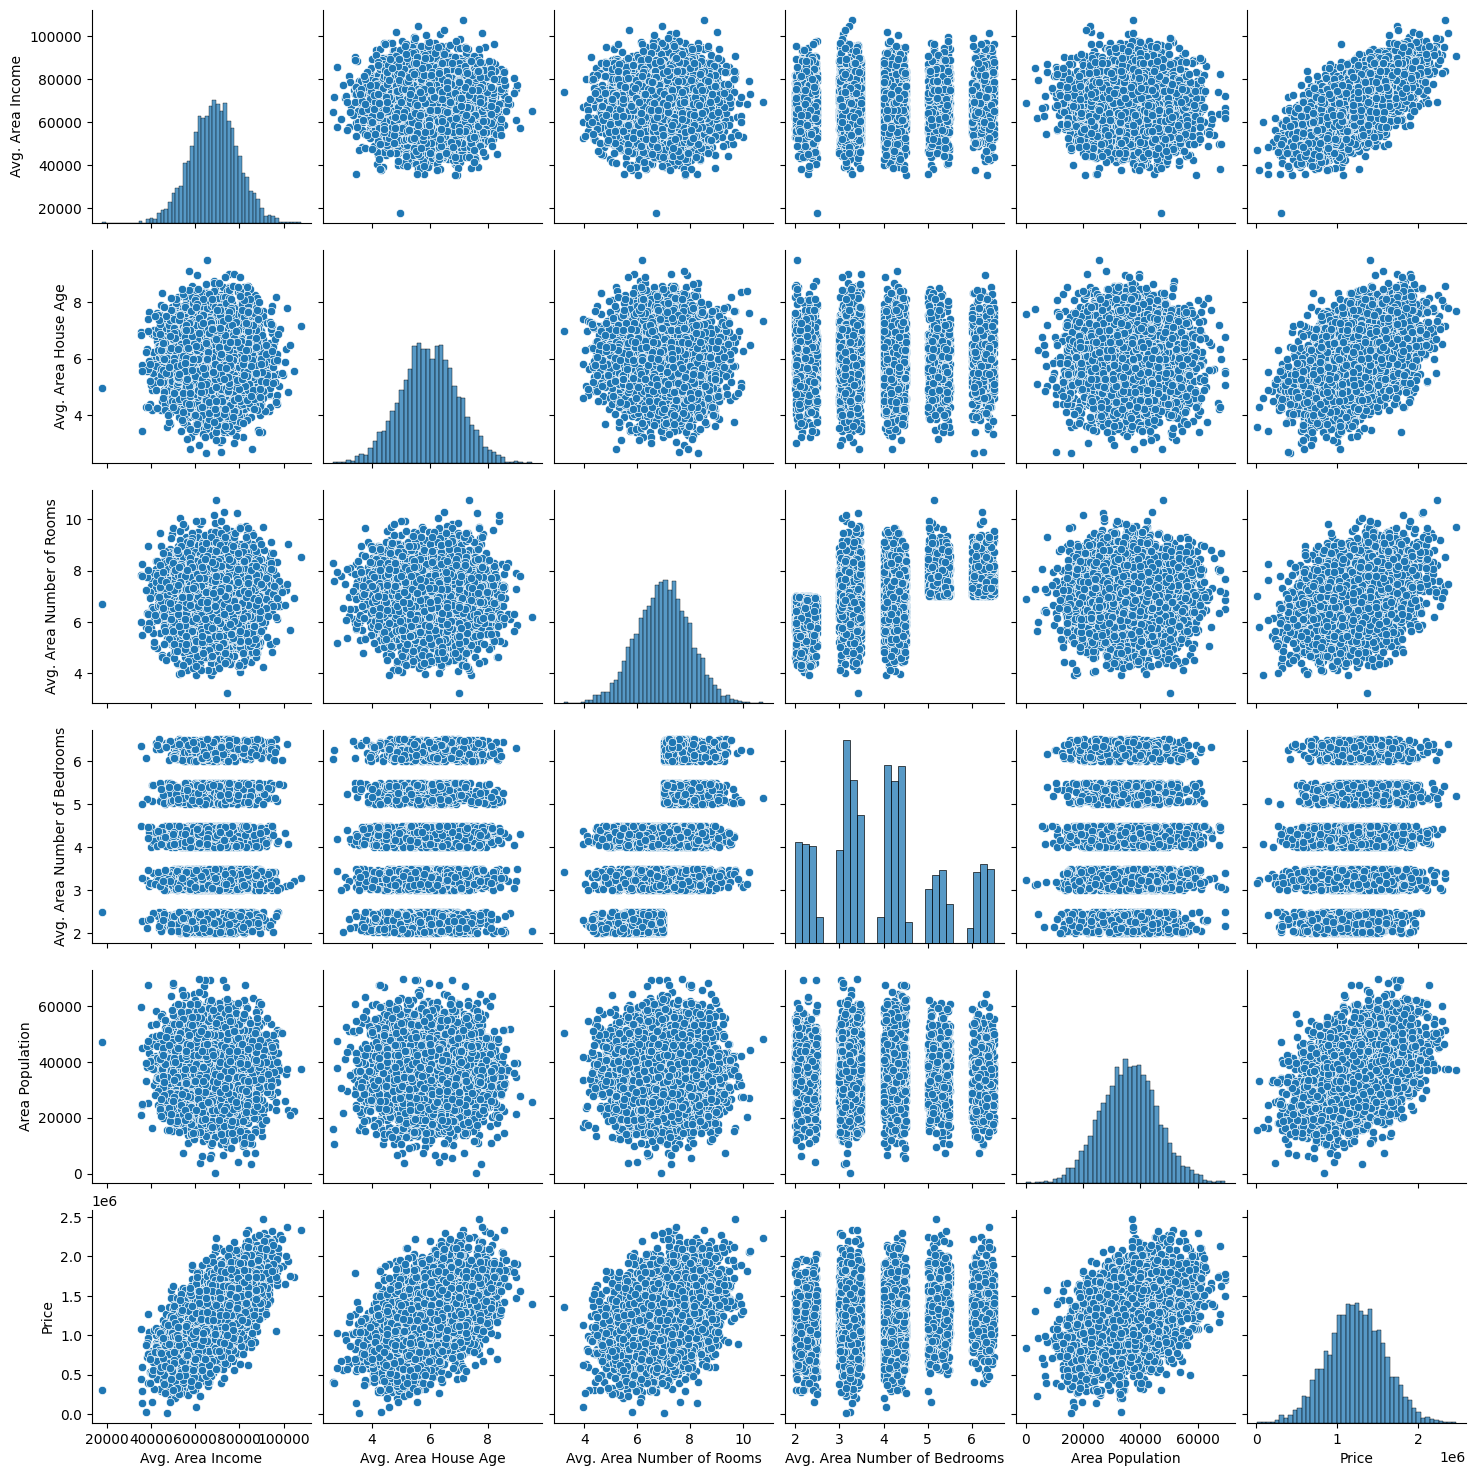

In [15]:
import seaborn as sns
sns.pairplot(data=df)

<Axes: >

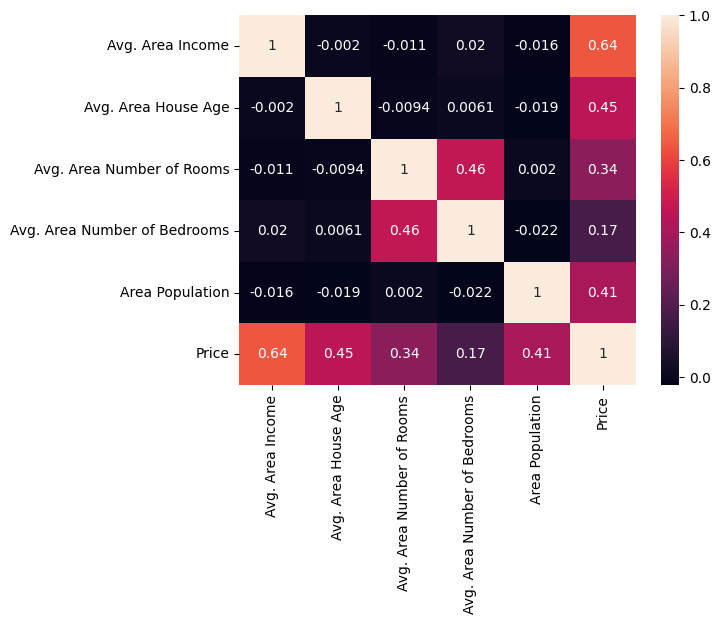

In [17]:
corr=df.corr()#corelation
sns.heatmap(data=corr,annot=True)

amra target hisebe price ke nilam.price er shate onnanno column er kmn relation dekhlam.price er shate sob theke besi relation ache (avg.area incom(0.64)) er.er por avg.area house age(0.45).....


In [ ]:
#separete data for train,test(split)
feature=df.drop(columns='Price')
feature.head()
#x=feture(input column)
#target(price) ke baki sob column ke x hisbe nibo

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086
1,79248.642455,6.002900,6.730821,3.09,40173
2,61287.067179,5.865890,8.512727,5.13,36882
3,63345.240046,7.188236,5.586729,3.26,34310
4,59982.197226,5.040555,7.839388,4.23,26354


In [ ]:
target=df['Price']#y==output column(jeita predict korbo)
target.head()

0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(feature,target,train_size=0.8,random_state=42)
#data set 80% jabee model ke train koranor jonee 20% jabee model ke test korar jonne jegula hide thake.

In [30]:
x_train


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
4227,66547.016454,5.846095,6.847298,4.13,27850
4676,53722.008599,6.401391,7.787764,3.30,47649
800,64838.492899,6.437157,8.699544,4.02,32921
3671,67097.092120,6.086754,7.211963,3.05,27191
4193,75245.465436,8.167820,7.420100,3.42,37410
...,...,...,...,...,...
4426,76223.561256,6.371627,5.342217,2.42,30165
466,56685.014442,6.958045,7.502115,3.38,43322
3092,66195.337714,6.507971,6.611861,3.14,37288
3772,58694.515017,7.394768,9.269453,4.32,49960


In [32]:
y_train

4227    1.094880e+06
4676    1.300389e+06
800     1.382172e+06
3671    1.027428e+06
4193    1.562887e+06
            ...     
4426    1.023944e+06
466     1.223101e+06
3092    1.318598e+06
3772    1.708631e+06
860     1.060898e+06
Name: Price, Length: 4000, dtype: float64

In [37]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()#creating object

In [40]:
lr.fit(x_train,y_train)#trained the model calculating m and c 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
lr.coef_#m

array([2.16522070e+01, 1.64666422e+05, 1.19624079e+05, 2.44034240e+03,
       1.52703170e+01])

In [44]:
pd.DataFrame(index=x_train.columns,data=lr.coef_)

,0
Avg. Area Income,21.652207
Avg. Area House Age,164666.421931
Avg. Area Number of Rooms,119624.079051
Avg. Area Number of Bedrooms,2440.342401
Area Population,15.270317


In [46]:
lr.intercept_#c

np.float64(-2635065.4884916963)

In [49]:
lr.predict(x_test)

array([1308581.0107105 , 1237042.56863858, 1243434.84263762,
       1228904.57446302, 1063321.17014603, 1544053.51357545,
       1094770.94545514,  833283.10748257,  788410.79652614,
       1469709.83960962,  671735.80497147, 1606819.15263984,
       1004169.54794021, 1796802.69031385, 1288561.01354503,
       1087784.17519405, 1423071.07868578, 1078181.39608624,
        802281.66179698,  930766.72405974, 1134823.10524423,
        916392.20953931, 1489976.29475067, 1284582.46134284,
       1582072.99980317, 1132520.43029576, 1089884.66029918,
        974517.98969004,  924052.81272318, 1740767.01023112,
       1286475.06419441, 1621288.83354311, 1435258.03072289,
       1234017.81013601, 1485430.66757188, 1718332.50963987,
       1538952.65157986,  777112.63837547, 1765196.33177908,
       1175964.84898447, 1553712.23269417,  897710.56326404,
       1371047.37775888,  845285.15158191, 1201028.74542879,
       1133292.79502999, 1363121.89135148, 1449818.91097435,
       1574368.95430021,

<Axes: xlabel='Price'>

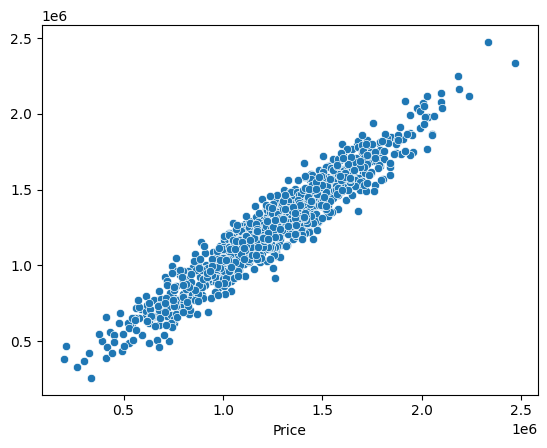

In [ ]:
sns.scatterplot(x=y_test,y=lr.predict(x_test))
#acctual Y and predicted Y